In [12]:
import numpy as np 
from uncertainties import ufloat
from uncertainties import unumpy as unp
from IPython.display import Latex, HTML, Math, display
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress
import pandas as pd
from scipy import constants as c
from matplotlib.patches import Rectangle
from matplotlib.ticker import MaxNLocator
from sklearn.metrics import r2_score


## Flavor


[0.05725553 0.06298108 0.06870663]
[1013.25000091 1013.15000091 1013.05000091]


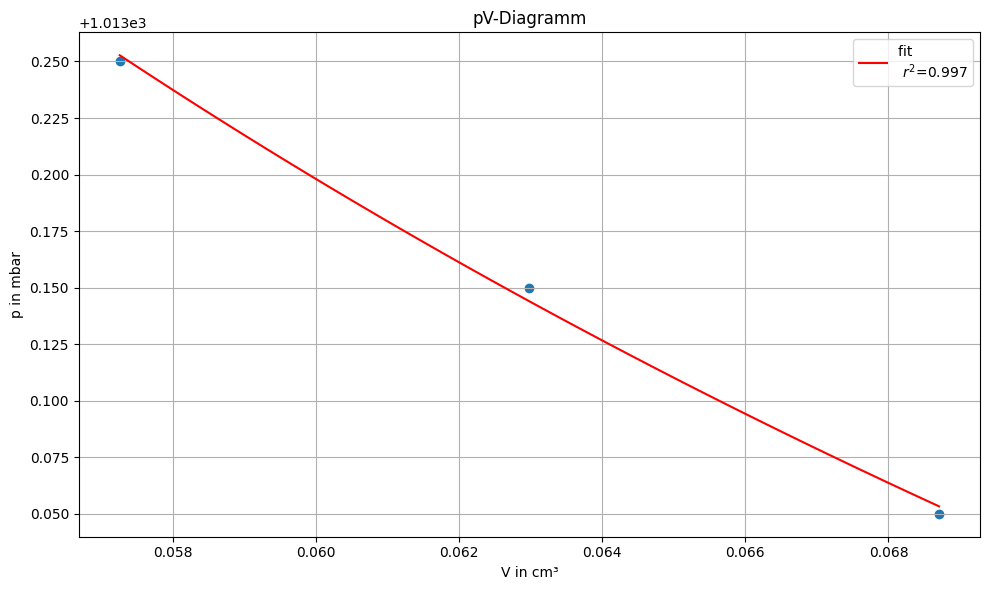

In [ ]:
# 2.2 Druck und Volumen konstante Temperatur

T_0 = 21        # °C
p_0 = 1013.25   # mbar
h_hg = 1        # cm

dp = np.array([0, 0.1, 0.2])*(-1)
h = np.array([1, 1.1, 1.2])

# Unsicherheiten

def Druck(dp, h, p_0):
    p_hg = c.gravitational_constant*h*136*100
    p = p_0 + dp + p_hg
    return p

def Volumen(h):
    V = c.pi*0.27**2*1/4*h
    return V

def model_f(x,a,b):
    return a/x + b


p = Druck(dp, h_hg, p_0)
V = Volumen(h)
print(V)
print(p)

popt, pcov = curve_fit(model_f, V, p, p0=[1,0])

a_opt, b_opt = popt
x_model = np.linspace(min(V), max(V), 100)
y_model = model_f(x_model, a_opt, b_opt)



def r2_curve_fit(popt, x, y):
    y_pred = model_f(x, *popt)
    r2 = r2_score(y, y_pred)
    return r2

r2 = r2_curve_fit(popt, V, p)


plt.figure(figsize=(10, 6))
plt.scatter(V, p)
plt.plot(x_model, y_model, color='r', label=f"fit \n $r^2$={r2:.3f}")
# plt.plot(V, p, "o")
plt.ylabel(r"p in mbar")
plt.xlabel(r"V in cm³")
plt.legend()
plt.title("pV-Diagramm")
plt.tight_layout()
plt.grid()
plt.show()

[0.05725553 0.06298108 0.06870663]


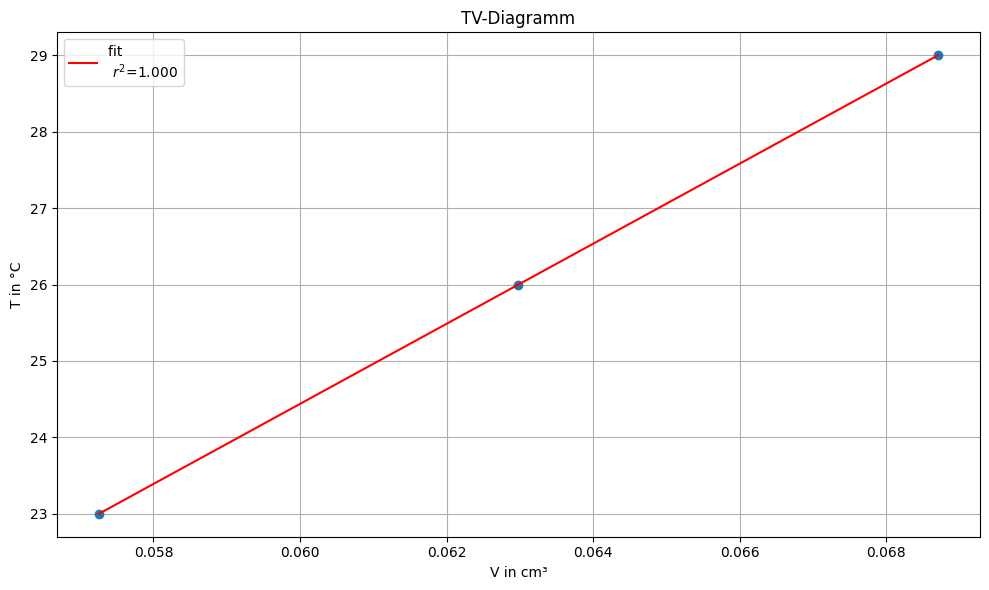

In [ ]:
# 2.2 Temperatur und Volumen konstante Druck

T_0 = 21        # °C
p_0 = 1013.25   # mbar
h_hg = 1        # cm

T = np.array([23, 26, 29])
h = np.array([1, 1.1, 1.2])

# Unsicherheiten
Tu = unp.uarray(T,3)

def r2_curve_fit(func, popt, x, y):
    y_pred = func(x, *popt)
    r2 = r2_score(y, y_pred)
    return r2


def Volumen(h):
    V = c.pi*0.27**2*1/4*h
    return V
V = Volumen(h)
print(V)

def linfit(x, a, b):
    return a*x+b

popt, pcov = curve_fit(linfit, V, T, p0=[1,100])

a_opt, b_opt = popt
x_model = np.linspace(min(V), max(V), 100)
y_model = linfit(x_model, a_opt, b_opt)

r2 = r2_curve_fit(linfit, popt, V, T)

plt.figure(figsize=(10, 6))
plt.plot(V, T, "o")
plt.plot(x_model, y_model, color='r', label=f"fit \n $r^2$={r2:.3f}")
plt.ylabel(r"T in °C")
plt.xlabel(r"V in cm³")
plt.legend()
plt.title("TV-Diagramm")
plt.tight_layout()
plt.grid()
plt.show()
print(Tu)

## Flavor

In [ ]:
# 3.2 Adiabatenexponent

